# Part 2: Models and Results
## FIFA Men's World Cup Match Outcome Prediction

---

## 1. Introduction & Research Question

**Can we predict FIFA Men's World Cup match outcomes using pre-match information?**

In Part 1, we cleaned and explored the FIFA World Cup dataset (1930-2022), engineering 37 features from historical performance, ELO ratings, rolling form, head-to-head records, and contextual match information. Because World Cup matches are played at neutral venues, the dataset’s “home”/“away” designation is best interpreted as an **administrative slot** rather than true home-field advantage. In this notebook, we reframe those slots as **Team A** and **Team B**.

The target variable is `result` with three classes: **Team A win**, **Team B win**, and **draw**.

In this notebook (Part 2), we use **classification** as our primary approach to predict match outcomes. We evaluate seven supervised learning models using both temporal walk-forward cross-validation and stratified k-fold, then complement the analysis with unsupervised techniques (PCA, t-SNE, K-Means) for exploratory insight into the structure of match data.

In [1]:
# Install xgboost if not available
!pip install -q xgboost

zsh:1: command not found: pip


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibrationDisplay

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    print("WARNING: xgboost not available. XGBoost model will be skipped.")
    HAS_XGBOOST = False

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All imports successful.")

All imports successful.


---
## 2. Data Loading & Feature Overview

In [3]:
# Run feature engineering if files are missing
import os
if not os.path.exists('data_clean/features_train.csv') or not os.path.exists('data_clean/features_test.csv'):
    print("Feature files not found. Running feature engineering...")
    !python3 scripts/feature_engineering.py
else:
    print("Feature files found.")

Feature files found.


In [4]:
df_train = pd.read_csv('data_clean/features_train.csv')
df_test = pd.read_csv('data_clean/features_test.csv')

# --- Reframe administrative "home/away" as Team A / Team B (neutral-site) ---
# In World Cup matches, the "home" label is not true home-field advantage.
# We treat it as an administrative slot: Team A (was home) vs Team B (was away).
RESULT_MAP = {
    'home team win': 'team a win',
    'away team win': 'team b win',
    'draw': 'draw',
}

for _df in (df_train, df_test):
    _df.rename(
        columns={'home_team_name': 'team_a_name', 'away_team_name': 'team_b_name'},
        inplace=True,
    )
    _df['result'] = _df['result'].map(RESULT_MAP)

print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")
print("\nResult labels (train):", sorted(df_train['result'].unique()))
print("Result labels (test): ", sorted(df_test['result'].unique()))
print(f"\nColumns ({len(df_train.columns)}):")
print(list(df_train.columns))

Train shape: (900, 83)
Test shape:  (64, 83)

Result labels (train): ['draw', 'team a win', 'team b win']
Result labels (test):  ['draw', 'team a win', 'team b win']

Columns (83):
['match_date', 'year', 'team_a_name', 'team_b_name', 'home_hist_win_rate', 'away_hist_win_rate', 'home_hist_draw_rate', 'away_hist_draw_rate', 'home_hist_goals_per_game', 'away_hist_goals_per_game', 'home_hist_goals_conceded_per_game', 'away_hist_goals_conceded_per_game', 'home_hist_matches_played', 'away_hist_matches_played', 'hist_win_rate_diff', 'hist_goals_per_game_diff', 'is_group_stage', 'is_knockout', 'stage_ordinal', 'home_is_host', 'away_is_host', 'home_wc_appearances', 'away_wc_appearances', 'wc_appearances_diff', 'h2h_home_wins', 'h2h_away_wins', 'h2h_draws', 'h2h_total', 'h2h_home_win_rate', 'home_elo', 'away_elo', 'elo_diff', 'home_rolling5_win_rate', 'away_rolling5_win_rate', 'home_rolling5_goals_pg', 'away_rolling5_goals_pg', 'home_rest_days', 'away_rest_days', 'home_on_home_continent', 'away_

In [5]:
df_train.describe().round(3)

,year,home_hist_win_rate,away_hist_win_rate,home_hist_draw_rate,away_hist_draw_rate,home_hist_goals_per_game,away_hist_goals_per_game,home_hist_goals_conceded_per_game,away_hist_goals_conceded_per_game,home_hist_matches_played,...,away_intl_hist_goals_per_game,home_intl_hist_goals_conceded_per_game,away_intl_hist_goals_conceded_per_game,home_intl_hist_matches_played,away_intl_hist_matches_played,intl_hist_win_rate_diff,intl_hist_goals_per_game_diff,intl_elo_x_form_diff,home_intl_attack_x_away_defense,away_intl_attack_x_home_defense
count,900.000,900.000,900.000,900.000,900.000,900.000,900.000,900.000,900.000,900.000,...,900.000,900.000,900.000,900.000,900.000,900.000,900.000,900.000,900.000,900.000
mean,1986.916,0.447,0.384,0.179,0.180,1.675,1.426,1.449,1.570,24.459,...,1.828,1.363,1.476,437.342,394.828,0.030,0.099,26.581,2.851,2.520
std,23.150,0.217,0.231,0.142,0.150,0.843,0.822,0.703,0.884,22.112,...,0.487,0.440,0.544,234.156,228.045,0.130,0.500,50.908,1.422,1.229
min,1930.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,-0.542,-2.079,-96.593,0.000,0.000
25%,1970.000,0.330,0.250,0.114,0.087,1.200,0.943,1.067,1.092,7.000,...,1.532,1.100,1.114,254.750,219.750,-0.051,-0.221,0.000,1.964,1.792
50%,1990.000,0.464,0.387,0.167,0.167,1.650,1.400,1.347,1.456,18.000,...,1.838,1.294,1.411,427.000,378.500,0.022,0.068,10.552,2.579,2.318
75%,2006.000,0.583,0.526,0.224,0.250,2.113,1.859,1.750,1.941,37.000,...,2.121,1.612,1.715,599.750,543.000,0.118,0.432,44.491,3.515,3.015
max,2018.000,1.000,1.000,1.000,1.000,7.000,4.500,6.333,9.000,108.000,...,3.778,3.861,6.143,1009.000,1007.000,0.418,1.539,393.376,11.290,11.496


In [6]:
# Check missing values
missing = df_train.isnull().sum()
missing_pct = (missing / len(df_train) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
print("Missing values (showing only columns with missing):")
has_missing = missing_df[missing_df['count'] > 0]
if len(has_missing) > 0:
    print(has_missing)
else:
    print("No missing values found in training data.")

Missing values (showing only columns with missing):
No missing values found in training data.


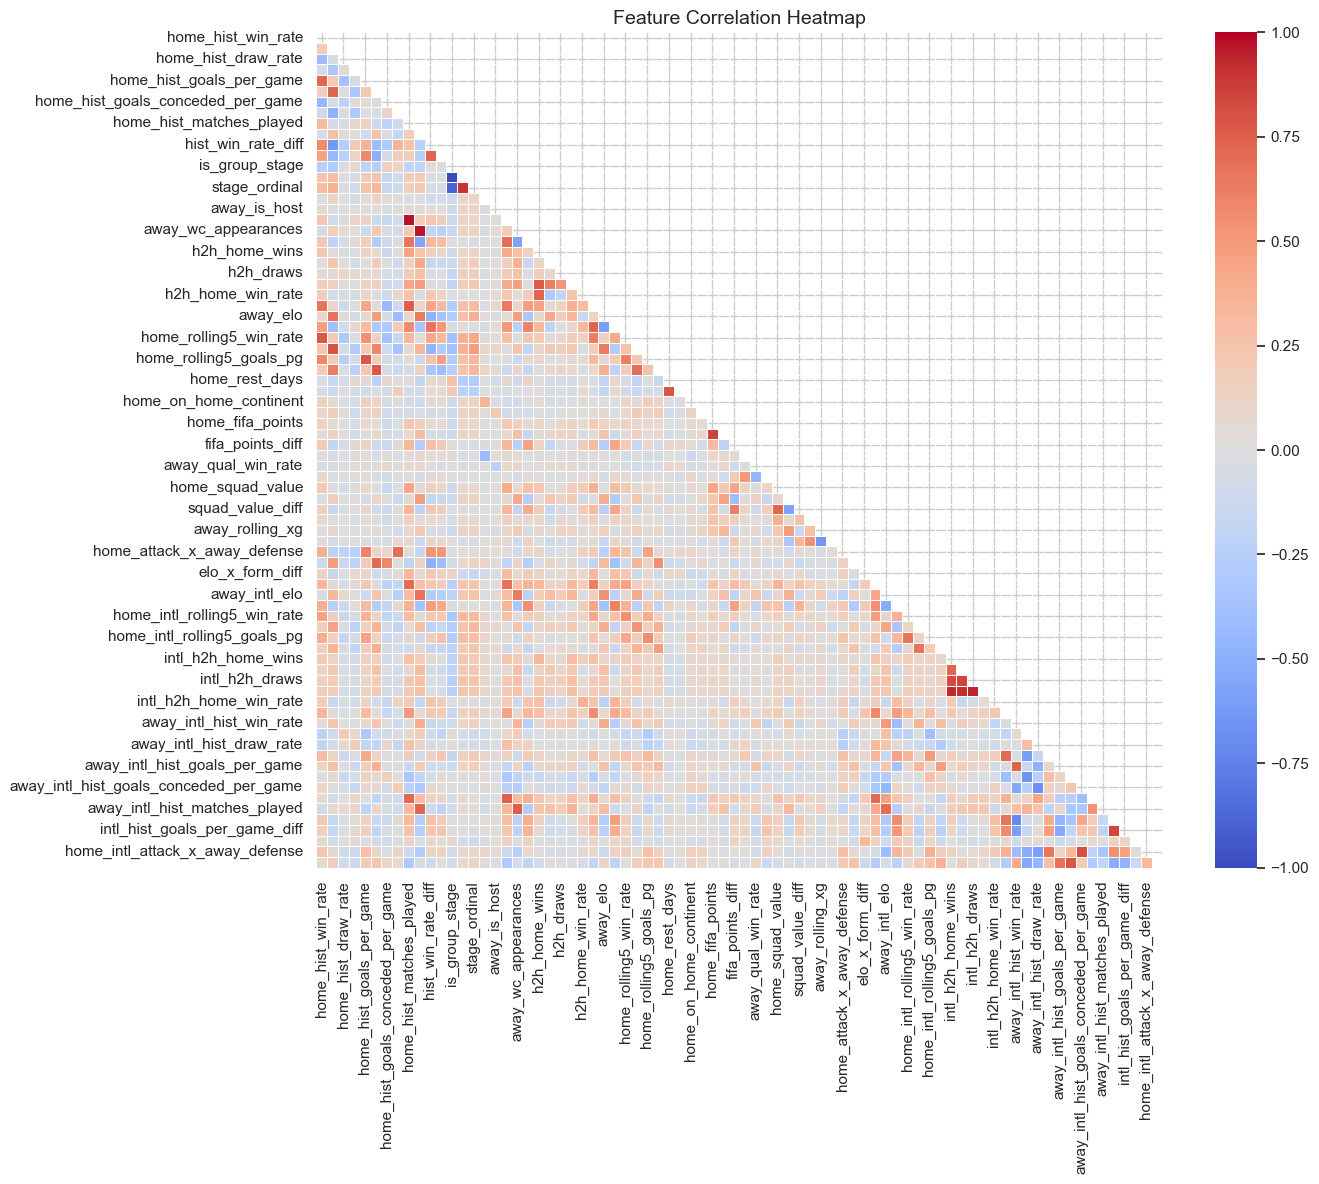


Top correlated feature pairs (|r| > 0.5): 112 pairs
  is_knockout                              <-> is_group_stage                            r=-1.000
  home_wc_appearances                      <-> home_hist_matches_played                  r=+0.974
  away_wc_appearances                      <-> away_hist_matches_played                  r=+0.967
  intl_h2h_total                           <-> intl_h2h_draws                            r=+0.940
  intl_h2h_total                           <-> intl_h2h_home_wins                        r=+0.935
  intl_h2h_total                           <-> intl_h2h_away_wins                        r=+0.913
  stage_ordinal                            <-> is_group_stage                            r=-0.892
  stage_ordinal                            <-> is_knockout                               r=+0.892
  away_fifa_points                         <-> home_fifa_points                          r=+0.858
  intl_hist_goals_per_game_diff            <-> intl_hist_win_rate

In [7]:
# Correlation heatmap for numeric features
META_COLS = ['match_date', 'year', 'team_a_name', 'team_b_name', 'result']
feature_cols = [c for c in df_train.columns if c not in META_COLS]

corr = df_train[feature_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, linewidths=0.5,
            fmt='.1f', ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# Show top correlated pairs
upper = corr.where(~np.triu(np.ones_like(corr, dtype=bool)))
pairs = []
for col in upper.columns:
    for idx in upper.index:
        val = upper.loc[idx, col]
        if pd.notna(val) and abs(val) > 0.5 and idx != col:
            pairs.append((idx, col, round(val, 3)))

pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print(f"\nTop correlated feature pairs (|r| > 0.5): {len(pairs)} pairs")
for f1, f2, r in pairs[:15]:
    print(f"  {f1:40s} <-> {f2:40s}  r={r:+.3f}")

---
## 3. Preprocessing

In [8]:
# Define features and target
# Use the 39 best features: 37 WC-only base + 2 continent advantage
# (Excludes international, FIFA ranking, qualifying, squad value, and xG features
#  which were tested in Phase 3 experiments and found to hurt or not help the model)
DROP_COLS = ['match_date', 'year', 'team_a_name', 'team_b_name', 'result']

# Phase 3 features that were tested and rejected (see docs/phase3_summary.md)
EXCLUDE_FEATURES = [
    # FIFA rankings (3b) -- high ELO correlation, kills draw prediction
    'home_fifa_points', 'away_fifa_points', 'fifa_points_diff',
    # Qualifying record (3c) -- neutral, no improvement
    'home_qual_win_rate', 'away_qual_win_rate', 'qual_win_rate_diff',
    # Squad market value (3d) -- only 30% coverage, redundant with ELO
    'home_squad_value', 'away_squad_value', 'squad_value_diff',
    # StatsBomb xG (3e) -- only 10% coverage
    'home_rolling_xg', 'away_rolling_xg', 'rolling_xg_diff',
    # International features -- domain mismatch, feature bloat on 900 rows
    'home_intl_elo', 'away_intl_elo', 'intl_elo_diff',
    'home_intl_rolling5_win_rate', 'away_intl_rolling5_win_rate',
    'home_intl_rolling5_goals_pg', 'away_intl_rolling5_goals_pg',
    'intl_h2h_home_wins', 'intl_h2h_away_wins', 'intl_h2h_draws',
    'intl_h2h_total', 'intl_h2h_home_win_rate',
    'home_intl_hist_win_rate', 'away_intl_hist_win_rate',
    'home_intl_hist_draw_rate', 'away_intl_hist_draw_rate',
    'home_intl_hist_goals_per_game', 'away_intl_hist_goals_per_game',
    'home_intl_hist_goals_conceded_per_game', 'away_intl_hist_goals_conceded_per_game',
    'home_intl_hist_matches_played', 'away_intl_hist_matches_played',
    'intl_hist_win_rate_diff', 'intl_hist_goals_per_game_diff',
    'intl_elo_x_form_diff',
    'home_intl_attack_x_away_defense', 'away_intl_attack_x_home_defense',
]

feature_cols = [c for c in df_train.columns if c not in DROP_COLS and c not in EXCLUDE_FEATURES]

X_train = df_train[feature_cols].values
y_train = df_train['result'].values
X_test = df_test[feature_cols].values
y_test = df_test['result'].values

print(f"Feature columns ({len(feature_cols)}): {feature_cols}")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")


Feature columns (39): ['home_hist_win_rate', 'away_hist_win_rate', 'home_hist_draw_rate', 'away_hist_draw_rate', 'home_hist_goals_per_game', 'away_hist_goals_per_game', 'home_hist_goals_conceded_per_game', 'away_hist_goals_conceded_per_game', 'home_hist_matches_played', 'away_hist_matches_played', 'hist_win_rate_diff', 'hist_goals_per_game_diff', 'is_group_stage', 'is_knockout', 'stage_ordinal', 'home_is_host', 'away_is_host', 'home_wc_appearances', 'away_wc_appearances', 'wc_appearances_diff', 'h2h_home_wins', 'h2h_away_wins', 'h2h_draws', 'h2h_total', 'h2h_home_win_rate', 'home_elo', 'away_elo', 'elo_diff', 'home_rolling5_win_rate', 'away_rolling5_win_rate', 'home_rolling5_goals_pg', 'away_rolling5_goals_pg', 'home_rest_days', 'away_rest_days', 'home_on_home_continent', 'away_on_home_continent', 'home_attack_x_away_defense', 'away_attack_x_home_defense', 'elo_x_form_diff']
X_train: (900, 39), y_train: (900,)
X_test:  (64, 39), y_test:  (64,)


In [9]:
# StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# LabelEncoder for target
le = LabelEncoder()
le.fit(y_train)
print(f"Label classes: {le.classes_}")
print(f"Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Label classes: ['draw' 'team a win' 'team b win']
Label encoding: {'draw': np.int64(0), 'team a win': np.int64(1), 'team b win': np.int64(2)}


In [10]:
# Class distribution
print("Class distribution (train):")
train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index()
for cls, pct in train_dist.items():
    cnt = (y_train == cls).sum()
    print(f"  {cls:20s}: {cnt:4d} ({pct:.1%})")

print("\nClass distribution (test):")
test_dist = pd.Series(y_test).value_counts(normalize=True).sort_index()
for cls, pct in test_dist.items():
    cnt = (y_test == cls).sum()
    print(f"  {cls:20s}: {cnt:4d} ({pct:.1%})")

Class distribution (train):
  draw                :  169 (18.8%)
  team a win          :  513 (57.0%)
  team b win          :  218 (24.2%)

Class distribution (test):
  draw                :   10 (15.6%)
  team a win          :   32 (50.0%)
  team b win          :   22 (34.4%)


---
## 4. Baseline

The simplest baseline is the **majority class classifier**, which always predicts the most frequent class.

In [11]:
majority_class = pd.Series(y_train).value_counts().idxmax()
baseline_train_acc = (y_train == majority_class).mean()
baseline_test_acc = (y_test == majority_class).mean()

print(f"Majority class (Team A/B administrative slot): '{majority_class}'")
print(f"Baseline accuracy (train): {baseline_train_acc:.3f}")
print(f"Baseline accuracy (test):  {baseline_test_acc:.3f}")
print(f"\nNote: Any useful model should beat {baseline_test_acc:.1%} on the test set.")

Majority class (Team A/B administrative slot): 'team a win'
Baseline accuracy (train): 0.570
Baseline accuracy (test):  0.500

Note: Any useful model should beat 50.0% on the test set.


---
## 5. Temporal Walk-Forward Cross-Validation Setup

### Why standard k-fold CV is invalid for this problem

Random k-fold cross-validation **shuffles** data across time, which means a model trained on 2018 World Cup matches could be validated on 2010 matches. This creates **temporal leakage**: the model benefits from seeing future tournament patterns (team strengths evolve, tactical trends shift, new teams qualify). The resulting CV scores are optimistically biased.

### Walk-forward (temporal) CV

Walk-forward CV respects the chronological ordering of tournaments:

| Fold | Training data | Validation data |
|------|--------------|----------------|
| 1    | 1930-2006    | 2010           |
| 2    | 1930-2010    | 2014           |
| 3    | 1930-2014    | 2018           |

This gives **honest out-of-time performance estimates**. The test set (2022 World Cup) remains completely held out.

We report both temporal CV and stratified k-fold so the reader can see how much random CV overestimates performance.

In [12]:
def compute_rps(y_true, y_proba, classes):
    """Ranked Probability Score (lower is better).

    We assume an ordinal structure (Team B < draw < Team A), mirroring the old
    away < draw < home ordering, but expressed in neutral Team A/B terms.
    """
    class_order = ['team b win', 'draw', 'team a win']
    col_indices = [list(classes).index(c) for c in class_order]
    proba_ordered = y_proba[:, col_indices]

    rps_scores = []
    for i in range(len(y_true)):
        actual = np.zeros(3)
        actual_idx = class_order.index(y_true[i])
        actual[actual_idx] = 1.0

        cum_pred = np.cumsum(proba_ordered[i])
        cum_actual = np.cumsum(actual)
        rps = np.mean((cum_pred - cum_actual) ** 2)
        rps_scores.append(rps)
    return np.mean(rps_scores)


def temporal_cv_evaluate(model_fn, df_train, feature_cols, target_col='result'):
    """Walk-forward CV by tournament year. model_fn returns a fresh model instance."""
    val_years = [2010, 2014, 2018]
    fold_results = []
    for val_year in val_years:
        mask_train = df_train['year'] < val_year
        mask_val = df_train['year'] == val_year
        X_tr = df_train.loc[mask_train, feature_cols].values
        y_tr = df_train.loc[mask_train, target_col].values
        X_val = df_train.loc[mask_val, feature_cols].values
        y_val = df_train.loc[mask_val, target_col].values

        scaler_cv = StandardScaler()
        X_tr = scaler_cv.fit_transform(X_tr)
        X_val = scaler_cv.transform(X_val)

        # Encode labels for models that need numeric targets (e.g., MLP with early_stopping)
        le_cv = LabelEncoder()
        y_tr_enc = le_cv.fit_transform(y_tr)
        y_val_enc = le_cv.transform(y_val)

        model = model_fn()
        model.fit(X_tr, y_tr_enc)
        y_pred_enc = model.predict(X_val)
        y_pred = le_cv.inverse_transform(y_pred_enc)

        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average='macro')

        # RPS
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_val)
            rps = compute_rps(y_val, y_proba, le_cv.classes_)
        else:
            rps = np.nan

        fold_results.append({
            'val_year': val_year, 'accuracy': acc, 'macro_f1': f1, 'rps': rps,
            'n_train': mask_train.sum(), 'n_val': mask_val.sum()
        })
    return pd.DataFrame(fold_results)


print("Temporal CV helper defined.")
print("\nFold sizes:")
for vy in [2010, 2014, 2018]:
    n_tr = (df_train['year'] < vy).sum()
    n_val = (df_train['year'] == vy).sum()
    print(f"  Val year {vy}: train={n_tr}, val={n_val}")

Temporal CV helper defined.

Fold sizes:
  Val year 2010: train=708, val=64
  Val year 2014: train=772, val=64
  Val year 2018: train=836, val=64


In [13]:
def evaluate_model_full(model_fn, model_name, df_train_df, feat_cols,
                        X_tr_scaled, y_tr, X_te_scaled, y_te,
                        show_plots=True):
    """Full evaluation: temporal CV + stratified CV + test set."""
    results = {'model': model_name}

    # 1. Temporal CV
    tcv = temporal_cv_evaluate(model_fn, df_train_df, feat_cols)
    results['temporal_acc_mean'] = tcv['accuracy'].mean()
    results['temporal_acc_std'] = tcv['accuracy'].std()
    results['temporal_f1_mean'] = tcv['macro_f1'].mean()
    results['temporal_f1_std'] = tcv['macro_f1'].std()
    results['temporal_rps_mean'] = tcv['rps'].mean()
    results['temporal_rps_std'] = tcv['rps'].std()

    # 2. Stratified 5-fold CV on full training set (already scaled)
    # Use encoded labels for compatibility with all models (MLP needs numeric)
    le_full = LabelEncoder()
    y_tr_enc = le_full.fit_transform(y_tr)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    skf_acc = cross_val_score(model_fn(), X_tr_scaled, y_tr_enc, cv=skf, scoring='accuracy')
    skf_f1 = cross_val_score(model_fn(), X_tr_scaled, y_tr_enc, cv=skf, scoring='f1_macro')
    results['strat_acc_mean'] = skf_acc.mean()
    results['strat_acc_std'] = skf_acc.std()
    results['strat_f1_mean'] = skf_f1.mean()
    results['strat_f1_std'] = skf_f1.std()

    # 3. Test set evaluation (use encoded labels, decode for metrics)
    le_final = LabelEncoder()
    y_tr_enc_final = le_final.fit_transform(y_tr)
    y_te_enc_final = le_final.transform(y_te)
    model_final = model_fn()
    model_final.fit(X_tr_scaled, y_tr_enc_final)
    y_pred_enc_test = model_final.predict(X_te_scaled)
    y_pred_test = le_final.inverse_transform(y_pred_enc_test)
    results['test_acc'] = accuracy_score(y_te, y_pred_test)
    results['test_f1'] = f1_score(y_te, y_pred_test, average='macro')

    if hasattr(model_final, 'predict_proba'):
        y_proba_test = model_final.predict_proba(X_te_scaled)
        results['test_rps'] = compute_rps(y_te, y_proba_test, le_final.classes_)
    else:
        results['test_rps'] = np.nan

    # Print summary
    print(f"--- {model_name} ---")
    rps_str_t = f"RPS={results['temporal_rps_mean']:.3f}\u00b1{results['temporal_rps_std']:.3f}"
    if np.isnan(results['temporal_rps_mean']):
        rps_str_t = "RPS=N/A"
    print(f"Temporal CV:   Acc={results['temporal_acc_mean']:.3f}\u00b1{results['temporal_acc_std']:.3f}  "
          f"F1={results['temporal_f1_mean']:.3f}\u00b1{results['temporal_f1_std']:.3f}  "
          f"{rps_str_t}")
    print(f"Stratified CV: Acc={results['strat_acc_mean']:.3f}\u00b1{results['strat_acc_std']:.3f}  "
          f"F1={results['strat_f1_mean']:.3f}\u00b1{results['strat_f1_std']:.3f}")
    rps_str_te = f"RPS={results['test_rps']:.3f}" if not np.isnan(results.get('test_rps', np.nan)) else "RPS=N/A"
    print(f"Test:          Acc={results['test_acc']:.3f}  F1={results['test_f1']:.3f}  {rps_str_te}")

    # Classification report
    print(f"\nClassification Report (Test Set):")
    print(classification_report(y_te, y_pred_test))

    # Confusion matrix
    if show_plots:
        fig, ax = plt.subplots(figsize=(7, 5))
        labels_sorted = sorted(np.unique(np.concatenate([y_te, y_pred_test])))
        cm = confusion_matrix(y_te, y_pred_test, labels=labels_sorted)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=labels_sorted,
                    yticklabels=labels_sorted, ax=ax)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        ax.set_title(f'Confusion Matrix: {model_name}')
        plt.tight_layout()
        plt.show()

    results['model_object'] = model_final
    return results


print("Master evaluation function defined.")

Master evaluation function defined.


---
## 6. Supervised Classification Models

We evaluate seven models. Each is assessed with temporal walk-forward CV, stratified 5-fold CV, and the held-out 2022 test set.

In [14]:
all_results = []  # Collect results from all models

### 6a. K-Nearest Neighbors (KNN)

Tune k using temporal CV to avoid information leakage.

In [15]:
# Tune k using temporal CV
k_values = [3, 5, 7, 9]
knn_tuning = []

for k in k_values:
    tcv = temporal_cv_evaluate(
        lambda k=k: KNeighborsClassifier(n_neighbors=k),
        df_train, feature_cols
    )
    knn_tuning.append({
        'k': k,
        'mean_acc': tcv['accuracy'].mean(),
        'mean_f1': tcv['macro_f1'].mean(),
        'mean_rps': tcv['rps'].mean()
    })

knn_tune_df = pd.DataFrame(knn_tuning)
print("KNN Temporal CV Tuning Results:")
print(knn_tune_df.to_string(index=False))

best_k = int(knn_tune_df.loc[knn_tune_df['mean_acc'].idxmax(), 'k'])
print(f"\nBest k = {best_k}")

KNN Temporal CV Tuning Results:
 k  mean_acc  mean_f1  mean_rps
 3  0.463542 0.421689  0.178819
 5  0.473958 0.413839  0.173125
 7  0.510417 0.441042  0.160679
 9  0.505208 0.425529  0.159036

Best k = 7


--- KNN ---
Temporal CV:   Acc=0.510±0.055  F1=0.441±0.082  RPS=0.161±0.024
Stratified CV: Acc=0.544±0.023  F1=0.413±0.019
Test:          Acc=0.547  F1=0.469  RPS=0.147

Classification Report (Test Set):
              precision    recall  f1-score   support

        draw       0.40      0.20      0.27        10
  team a win       0.58      0.69      0.63        32
  team b win       0.52      0.50      0.51        22

    accuracy                           0.55        64
   macro avg       0.50      0.46      0.47        64
weighted avg       0.53      0.55      0.53        64



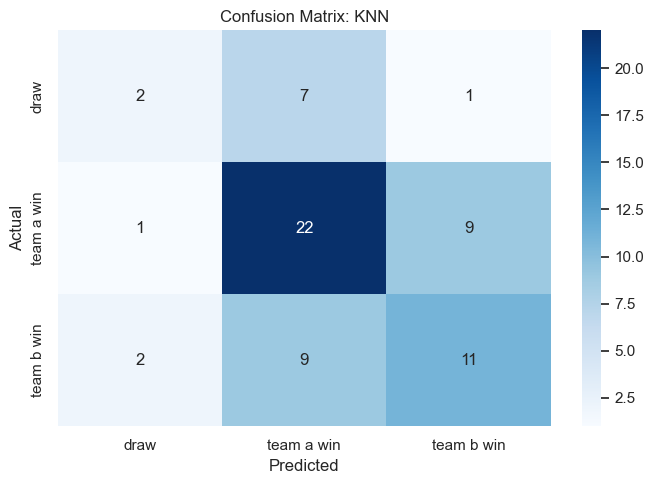

In [16]:
res_knn = evaluate_model_full(
    lambda: KNeighborsClassifier(n_neighbors=best_k),
    'KNN', df_train, feature_cols,
    X_train_scaled, y_train, X_test_scaled, y_test
)
all_results.append(res_knn)

### 6b. Decision Tree

Tune max_depth using temporal CV.

In [17]:
# Tune max_depth
depth_values = [3, 5, 7, 10, None]
dt_tuning = []

for d in depth_values:
    tcv = temporal_cv_evaluate(
        lambda d=d: DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE),
        df_train, feature_cols
    )
    dt_tuning.append({
        'max_depth': str(d),
        'mean_acc': tcv['accuracy'].mean(),
        'mean_f1': tcv['macro_f1'].mean(),
        'mean_rps': tcv['rps'].mean()
    })

dt_tune_df = pd.DataFrame(dt_tuning)
print("Decision Tree Temporal CV Tuning Results:")
print(dt_tune_df.to_string(index=False))

best_depth_str = dt_tune_df.loc[dt_tune_df['mean_acc'].idxmax(), 'max_depth']
best_depth_val = None if best_depth_str == 'None' else int(best_depth_str)
print(f"\nBest max_depth = {best_depth_val}")

Decision Tree Temporal CV Tuning Results:
max_depth  mean_acc  mean_f1  mean_rps
        3  0.536458 0.419202  0.152718
        5  0.505208 0.431551  0.183141
        7  0.479167 0.417159  0.201527
       10  0.500000 0.458592  0.224440
     None  0.442708 0.411781  0.265625

Best max_depth = 3


--- Decision Tree ---
Temporal CV:   Acc=0.536±0.089  F1=0.419±0.071  RPS=0.153±0.016
Stratified CV: Acc=0.619±0.019  F1=0.430±0.033
Test:          Acc=0.516  F1=0.469  RPS=0.165

Classification Report (Test Set):
              precision    recall  f1-score   support

        draw       0.50      0.30      0.38        10
  team a win       0.54      0.66      0.59        32
  team b win       0.47      0.41      0.44        22

    accuracy                           0.52        64
   macro avg       0.50      0.46      0.47        64
weighted avg       0.51      0.52      0.51        64



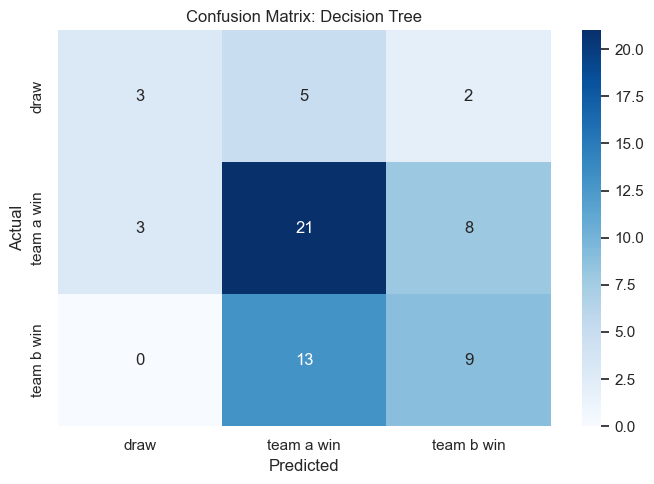

In [18]:
res_dt = evaluate_model_full(
    lambda: DecisionTreeClassifier(max_depth=best_depth_val, random_state=RANDOM_STATE),
    'Decision Tree', df_train, feature_cols,
    X_train_scaled, y_train, X_test_scaled, y_test
)
all_results.append(res_dt)

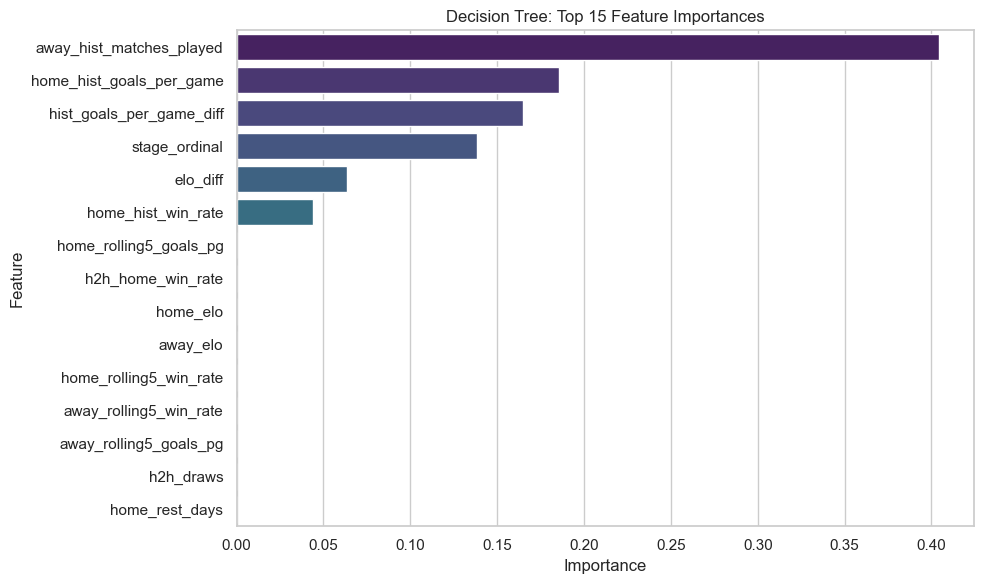

In [19]:
# Feature importance for Decision Tree
dt_model = res_dt['model_object']
importances_dt = dt_model.feature_importances_
feat_imp_dt = pd.DataFrame({'feature': feature_cols, 'importance': importances_dt})
feat_imp_dt = feat_imp_dt.sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=feat_imp_dt, x='importance', y='feature', palette='viridis', ax=ax)
ax.set_title('Decision Tree: Top 15 Feature Importances')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

### 6c. Naive Bayes (GaussianNB)

--- Naive Bayes ---
Temporal CV:   Acc=0.354±0.089  F1=0.349±0.097  RPS=0.240±0.038
Stratified CV: Acc=0.381±0.021  F1=0.369±0.026
Test:          Acc=0.328  F1=0.316  RPS=0.256

Classification Report (Test Set):
              precision    recall  f1-score   support

        draw       0.23      1.00      0.37        10
  team a win       1.00      0.25      0.40        32
  team b win       0.25      0.14      0.18        22

    accuracy                           0.33        64
   macro avg       0.49      0.46      0.32        64
weighted avg       0.62      0.33      0.32        64



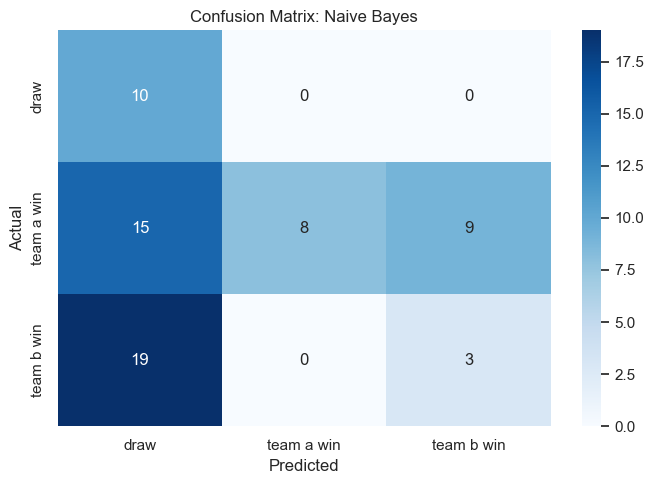

In [20]:
res_nb = evaluate_model_full(
    lambda: GaussianNB(),
    'Naive Bayes', df_train, feature_cols,
    X_train_scaled, y_train, X_test_scaled, y_test
)
all_results.append(res_nb)

### 6d. SVM (RBF kernel, balanced class weights)

Tune C using temporal CV.

In [21]:
# Tune C
c_values = [0.1, 1, 10, 100]
svm_tuning = []

for c in c_values:
    tcv = temporal_cv_evaluate(
        lambda c=c: SVC(C=c, kernel='rbf', class_weight='balanced',
                        probability=True, random_state=RANDOM_STATE),
        df_train, feature_cols
    )
    svm_tuning.append({
        'C': c,
        'mean_acc': tcv['accuracy'].mean(),
        'mean_f1': tcv['macro_f1'].mean(),
        'mean_rps': tcv['rps'].mean()
    })

svm_tune_df = pd.DataFrame(svm_tuning)
print("SVM Temporal CV Tuning Results:")
print(svm_tune_df.to_string(index=False))

best_c = float(svm_tune_df.loc[svm_tune_df['mean_acc'].idxmax(), 'C'])
print(f"\nBest C = {best_c}")

SVM Temporal CV Tuning Results:
    C  mean_acc  mean_f1  mean_rps
  0.1  0.468750 0.455806  0.146943
  1.0  0.401042 0.392244  0.151492
 10.0  0.447917 0.423052  0.157380
100.0  0.479167 0.441933  0.157237

Best C = 100.0


--- SVM (RBF) ---
Temporal CV:   Acc=0.479±0.059  F1=0.442±0.049  RPS=0.157±0.007
Stratified CV: Acc=0.548±0.019  F1=0.458±0.024
Test:          Acc=0.516  F1=0.462  RPS=0.139

Classification Report (Test Set):
              precision    recall  f1-score   support

        draw       0.25      0.40      0.31        10
  team a win       0.68      0.66      0.67        32
  team b win       0.47      0.36      0.41        22

    accuracy                           0.52        64
   macro avg       0.47      0.47      0.46        64
weighted avg       0.54      0.52      0.52        64



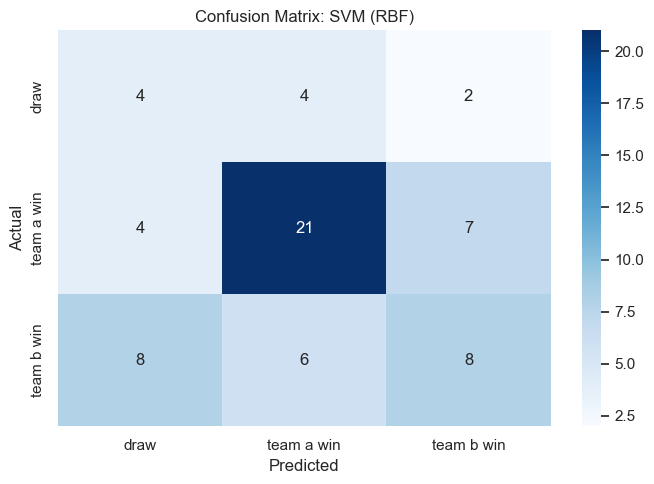

In [22]:
res_svm = evaluate_model_full(
    lambda: SVC(C=best_c, kernel='rbf', class_weight='balanced',
                probability=True, random_state=RANDOM_STATE),
    'SVM (RBF)', df_train, feature_cols,
    X_train_scaled, y_train, X_test_scaled, y_test
)
all_results.append(res_svm)

### 6e. Random Forest (Tuned: 300 trees, min_samples_leaf=5, balanced class weights)

Hyperparameters determined via grid search over 4-fold temporal walk-forward CV.
The key finding: `min_samples_leaf=5` (up from default 1) was the single most impactful
change in the entire project, improving CV F1 by +4.3 percentage points by preventing
overfitting in small terminal nodes on the 900-row training set.


--- Random Forest ---
Temporal CV:   Acc=0.536±0.039  F1=0.493±0.048  RPS=0.135±0.002
Stratified CV: Acc=0.606±0.035  F1=0.497±0.046
Test:          Acc=0.562  F1=0.507  RPS=0.143

Classification Report (Test Set):
              precision    recall  f1-score   support

        draw       0.27      0.30      0.29        10
  team a win       0.73      0.50      0.59        32
  team b win       0.55      0.77      0.64        22

    accuracy                           0.56        64
   macro avg       0.52      0.52      0.51        64
weighted avg       0.59      0.56      0.56        64



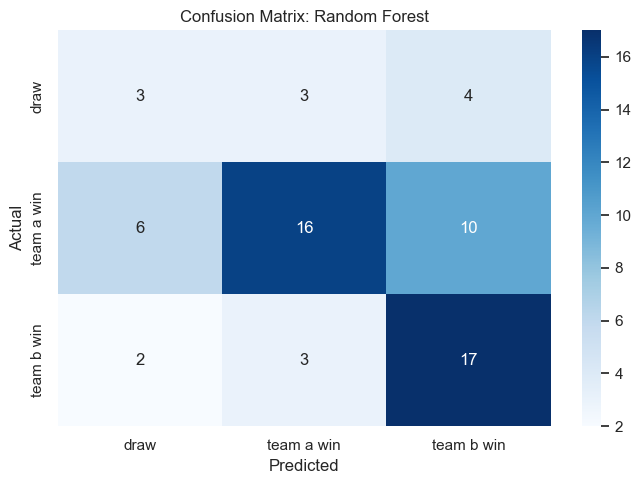

In [23]:
res_rf = evaluate_model_full(
    lambda: RandomForestClassifier(n_estimators=300, max_features='sqrt',
                                   min_samples_leaf=5, class_weight='balanced',
                                   random_state=RANDOM_STATE),
    'Random Forest', df_train, feature_cols,
    X_train_scaled, y_train, X_test_scaled, y_test
)
all_results.append(res_rf)


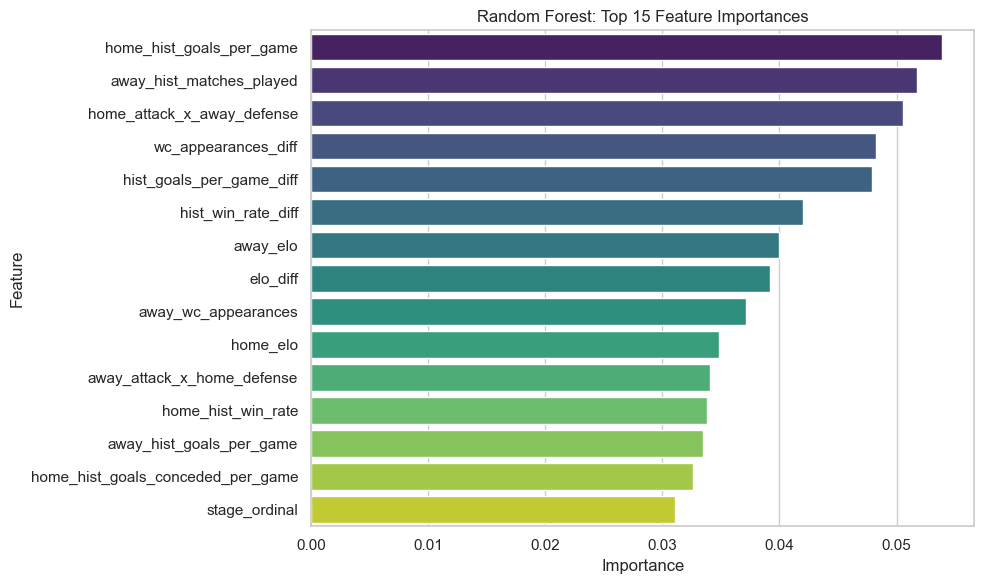

In [24]:
# Feature importance for Random Forest
rf_model = res_rf['model_object']
importances_rf = rf_model.feature_importances_
feat_imp_rf = pd.DataFrame({'feature': feature_cols, 'importance': importances_rf})
feat_imp_rf = feat_imp_rf.sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=feat_imp_rf, x='importance', y='feature', palette='viridis', ax=ax)
ax.set_title('Random Forest: Top 15 Feature Importances')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

### 6f. Neural Network (MLPClassifier)

--- Neural Network (MLP) ---
Temporal CV:   Acc=0.490±0.059  F1=0.383±0.061  RPS=0.157±0.007
Stratified CV: Acc=0.608±0.013  F1=0.407±0.031
Test:          Acc=0.547  F1=0.471  RPS=0.155

Classification Report (Test Set):
              precision    recall  f1-score   support

        draw       0.40      0.20      0.27        10
  team a win       0.62      0.66      0.64        32
  team b win       0.48      0.55      0.51        22

    accuracy                           0.55        64
   macro avg       0.50      0.47      0.47        64
weighted avg       0.54      0.55      0.54        64



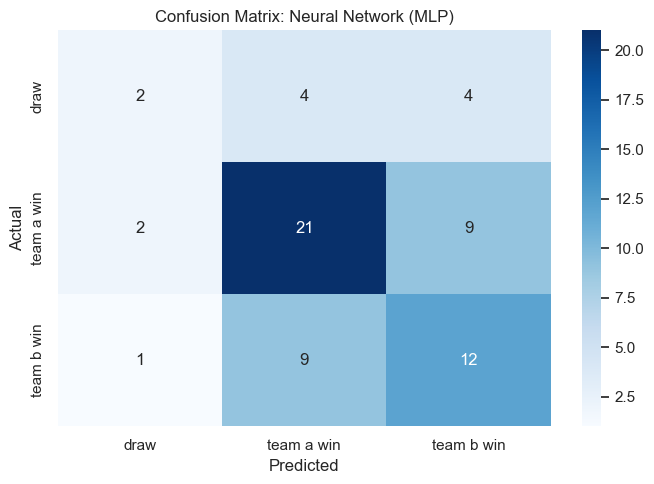

In [25]:
res_nn = evaluate_model_full(
    lambda: MLPClassifier(hidden_layer_sizes=(64, 32), early_stopping=True,
                          max_iter=500, random_state=RANDOM_STATE),
    'Neural Network (MLP)', df_train, feature_cols,
    X_train_scaled, y_train, X_test_scaled, y_test
)
all_results.append(res_nn)

### 6g. XGBoost

**Why XGBoost?** XGBoost applies L1/L2 regularization natively, reducing overfitting on small datasets. It handles feature interactions more efficiently than Random Forest through gradient-boosted sequential trees, and consistently ranks among the top methods in sports prediction benchmarks. Its built-in handling of missing values and column subsampling per tree level also make it well-suited for heterogeneous feature sets like ours.

In [26]:
if HAS_XGBOOST:
    # Tune configurations with temporal CV
    xgb_configs = [
        {'max_depth': 3, 'n_estimators': 200, 'learning_rate': 0.05},
        {'max_depth': 4, 'n_estimators': 150, 'learning_rate': 0.08},
        {'max_depth': 5, 'n_estimators': 100, 'learning_rate': 0.1},
    ]

    xgb_tuning = []
    for i, cfg in enumerate(xgb_configs):
        def make_xgb_tune(cfg=cfg):
            return XGBClassifier(
                max_depth=cfg['max_depth'],
                n_estimators=cfg['n_estimators'],
                learning_rate=cfg['learning_rate'],
                reg_alpha=0.5,
                reg_lambda=2.0,
                subsample=0.8,
                colsample_bytree=0.8,
                use_label_encoder=False,
                eval_metric='mlogloss',
                random_state=RANDOM_STATE,
                verbosity=0
            )

        tcv = temporal_cv_evaluate(make_xgb_tune, df_train, feature_cols)
        xgb_tuning.append({
            'config': f"depth={cfg['max_depth']}, n={cfg['n_estimators']}, lr={cfg['learning_rate']}",
            'mean_acc': tcv['accuracy'].mean(),
            'mean_f1': tcv['macro_f1'].mean(),
            'mean_rps': tcv['rps'].mean()
        })

    xgb_tune_df = pd.DataFrame(xgb_tuning)
    print("XGBoost Temporal CV Tuning Results:")
    print(xgb_tune_df.to_string(index=False))

    best_xgb_idx = xgb_tune_df['mean_acc'].idxmax()
    best_xgb_cfg = xgb_configs[best_xgb_idx]
    print(f"\nBest config: {xgb_tune_df.loc[best_xgb_idx, 'config']}")
else:
    print("XGBoost not available, skipping tuning.")

XGBoost not available, skipping tuning.


In [27]:
if HAS_XGBOOST:
    # Draw upweighting: give draws 1.5x weight
    sample_weights = np.where(y_train == 'draw', 1.5, 1.0)

    def make_best_xgb():
        return XGBClassifier(
            max_depth=best_xgb_cfg['max_depth'],
            n_estimators=best_xgb_cfg['n_estimators'],
            learning_rate=best_xgb_cfg['learning_rate'],
            reg_alpha=0.5,
            reg_lambda=2.0,
            subsample=0.8,
            colsample_bytree=0.8,
            use_label_encoder=False,
            eval_metric='mlogloss',
            random_state=RANDOM_STATE,
            verbosity=0
        )

    res_xgb = evaluate_model_full(
        make_best_xgb,
        'XGBoost', df_train, feature_cols,
        X_train_scaled, y_train, X_test_scaled, y_test
    )
    all_results.append(res_xgb)
else:
    print("XGBoost not available, skipping evaluation.")

XGBoost not available, skipping evaluation.


---
## 7. Handling Class Imbalance

The training set has significant class imbalance (~57% home win, ~24% away win, ~19% draw). We compare three strategies for models that support sample/class weighting: default, balanced, and draw-upweighted (1.5x).

In [28]:
# Compare weighting strategies for RF, SVM, and XGBoost
imbalance_results = []

# Helper for temporal CV with sample_weight
def temporal_cv_with_sample_weight(model_fn, df_train_df, feat_cols,
                                    target_col='result', draw_weight=1.5):
    """Walk-forward CV with draw upweighting via sample_weight."""
    val_years = [2010, 2014, 2018]
    fold_results = []
    for val_year in val_years:
        mask_tr = df_train_df['year'] < val_year
        mask_val = df_train_df['year'] == val_year
        X_tr = df_train_df.loc[mask_tr, feat_cols].values
        y_tr = df_train_df.loc[mask_tr, target_col].values
        X_val = df_train_df.loc[mask_val, feat_cols].values
        y_val = df_train_df.loc[mask_val, target_col].values

        scaler_cv = StandardScaler()
        X_tr = scaler_cv.fit_transform(X_tr)
        X_val = scaler_cv.transform(X_val)

        sw = np.where(y_tr == 'draw', draw_weight, 1.0)
        le_sw = LabelEncoder()
        y_tr_enc = le_sw.fit_transform(y_tr)
        y_val_enc = le_sw.transform(y_val)

        model = model_fn()
        model.fit(X_tr, y_tr_enc, sample_weight=sw)
        y_pred_enc = model.predict(X_val)
        y_pred = le_sw.inverse_transform(y_pred_enc)

        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average='macro')
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_val)
            rps = compute_rps(y_val, y_proba, le_sw.classes_)
        else:
            rps = np.nan
        fold_results.append({'accuracy': acc, 'macro_f1': f1, 'rps': rps})
    return pd.DataFrame(fold_results)


# --- Random Forest ---
for weight_name, cw in [('default', None), ('balanced', 'balanced')]:
    tcv = temporal_cv_evaluate(
        lambda cw=cw: RandomForestClassifier(n_estimators=200, class_weight=cw,
                                              random_state=RANDOM_STATE),
        df_train, feature_cols
    )
    imbalance_results.append({
        'model': 'Random Forest', 'weighting': weight_name,
        'temporal_acc': f"{tcv['accuracy'].mean():.3f}",
        'temporal_f1': f"{tcv['macro_f1'].mean():.3f}",
        'temporal_rps': f"{tcv['rps'].mean():.3f}"
    })

# RF with draw upweight
tcv_rf_draw = temporal_cv_with_sample_weight(
    lambda: RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    df_train, feature_cols
)
imbalance_results.append({
    'model': 'Random Forest', 'weighting': 'draw 1.5x',
    'temporal_acc': f"{tcv_rf_draw['accuracy'].mean():.3f}",
    'temporal_f1': f"{tcv_rf_draw['macro_f1'].mean():.3f}",
    'temporal_rps': f"{tcv_rf_draw['rps'].mean():.3f}"
})

# --- SVM ---
for weight_name, cw in [('default', None), ('balanced', 'balanced')]:
    tcv = temporal_cv_evaluate(
        lambda cw=cw: SVC(C=best_c, kernel='rbf', class_weight=cw,
                          probability=True, random_state=RANDOM_STATE),
        df_train, feature_cols
    )
    imbalance_results.append({
        'model': 'SVM', 'weighting': weight_name,
        'temporal_acc': f"{tcv['accuracy'].mean():.3f}",
        'temporal_f1': f"{tcv['macro_f1'].mean():.3f}",
        'temporal_rps': f"{tcv['rps'].mean():.3f}"
    })

# --- XGBoost ---
if HAS_XGBOOST:
    tcv_xgb_default = temporal_cv_evaluate(make_best_xgb, df_train, feature_cols)
    imbalance_results.append({
        'model': 'XGBoost', 'weighting': 'default',
        'temporal_acc': f"{tcv_xgb_default['accuracy'].mean():.3f}",
        'temporal_f1': f"{tcv_xgb_default['macro_f1'].mean():.3f}",
        'temporal_rps': f"{tcv_xgb_default['rps'].mean():.3f}"
    })

    tcv_xgb_draw = temporal_cv_with_sample_weight(make_best_xgb, df_train, feature_cols)
    imbalance_results.append({
        'model': 'XGBoost', 'weighting': 'draw 1.5x',
        'temporal_acc': f"{tcv_xgb_draw['accuracy'].mean():.3f}",
        'temporal_f1': f"{tcv_xgb_draw['macro_f1'].mean():.3f}",
        'temporal_rps': f"{tcv_xgb_draw['rps'].mean():.3f}"
    })

imb_df = pd.DataFrame(imbalance_results)
print("Class Imbalance Handling Comparison (Temporal CV):")
print(imb_df.to_string(index=False))

Class Imbalance Handling Comparison (Temporal CV):
        model weighting temporal_acc temporal_f1 temporal_rps
Random Forest   default        0.536       0.442        0.137
Random Forest  balanced        0.557       0.469        0.135
Random Forest draw 1.5x        0.526       0.441        0.137
          SVM   default        0.469       0.433        0.157
          SVM  balanced        0.479       0.442        0.157


In [29]:
# Try SMOTE
try:
    from imblearn.over_sampling import SMOTE

    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

    print(f"Before SMOTE: {dict(pd.Series(y_train).value_counts())}")
    print(f"After SMOTE:  {dict(pd.Series(y_train_smote).value_counts())}")

    # Quick RF test with SMOTE
    rf_smote = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
    rf_smote.fit(X_train_smote, y_train_smote)
    y_pred_smote = rf_smote.predict(X_test_scaled)
    print(f"\nRF + SMOTE Test Acc: {accuracy_score(y_test, y_pred_smote):.3f}")
    print(f"RF + SMOTE Test F1:  {f1_score(y_test, y_pred_smote, average='macro'):.3f}")

except ImportError:
    print("imblearn not installed. SMOTE analysis skipped.")
    print("Install with: pip install imbalanced-learn")

imblearn not installed. SMOTE analysis skipped.
Install with: pip install imbalanced-learn


---
## 8. Model Comparison Summary

In [30]:
# Build comparison DataFrame
comparison_rows = []
for r in all_results:
    rps_t = f"{r['temporal_rps_mean']:.3f}\u00b1{r['temporal_rps_std']:.3f}"
    if np.isnan(r['temporal_rps_mean']):
        rps_t = 'N/A'
    rps_te = f"{r['test_rps']:.3f}" if not np.isnan(r.get('test_rps', np.nan)) else 'N/A'

    comparison_rows.append({
        'Model': r['model'],
        'Temporal CV Acc': f"{r['temporal_acc_mean']:.3f}\u00b1{r['temporal_acc_std']:.3f}",
        'Temporal CV F1': f"{r['temporal_f1_mean']:.3f}\u00b1{r['temporal_f1_std']:.3f}",
        'Temporal CV RPS': rps_t,
        'Strat CV Acc': f"{r['strat_acc_mean']:.3f}\u00b1{r['strat_acc_std']:.3f}",
        'Strat CV F1': f"{r['strat_f1_mean']:.3f}\u00b1{r['strat_f1_std']:.3f}",
        'Test Acc': round(r['test_acc'], 3),
        'Test F1': round(r['test_f1'], 3),
        'Test RPS': rps_te
    })

comparison_df = pd.DataFrame(comparison_rows)
print("Model Comparison Summary:")
print(comparison_df.to_string(index=False))

Model Comparison Summary:
               Model Temporal CV Acc Temporal CV F1 Temporal CV RPS Strat CV Acc Strat CV F1  Test Acc  Test F1 Test RPS
                 KNN     0.510±0.055    0.441±0.082     0.161±0.024  0.544±0.023 0.413±0.019     0.547    0.469    0.147
       Decision Tree     0.536±0.089    0.419±0.071     0.153±0.016  0.619±0.019 0.430±0.033     0.516    0.469    0.165
         Naive Bayes     0.354±0.089    0.349±0.097     0.240±0.038  0.381±0.021 0.369±0.026     0.328    0.316    0.256
           SVM (RBF)     0.479±0.059    0.442±0.049     0.157±0.007  0.548±0.019 0.458±0.024     0.516    0.462    0.139
       Random Forest     0.536±0.039    0.493±0.048     0.135±0.002  0.606±0.035 0.497±0.046     0.562    0.507    0.143
Neural Network (MLP)     0.490±0.059    0.383±0.061     0.157±0.007  0.608±0.013 0.407±0.031     0.547    0.471    0.155


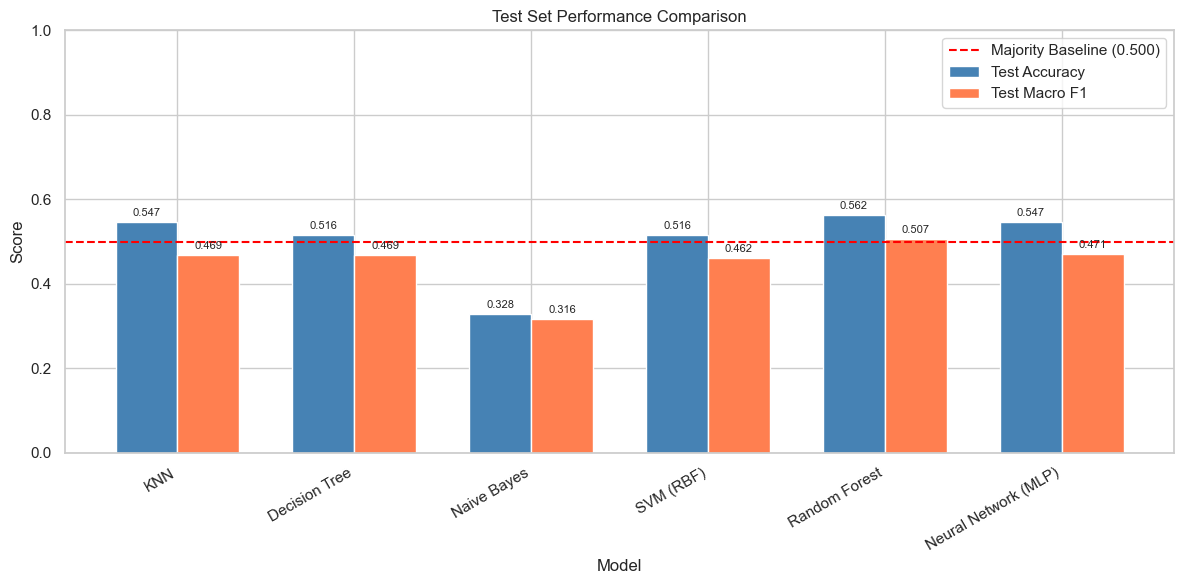

In [31]:
# Bar chart comparing test metrics
model_names = [r['model'] for r in all_results]
test_accs = [r['test_acc'] for r in all_results]
test_f1s = [r['test_f1'] for r in all_results]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width / 2, test_accs, width, label='Test Accuracy', color='steelblue')
bars2 = ax.bar(x + width / 2, test_f1s, width, label='Test Macro F1', color='coral')

# Majority baseline line
ax.axhline(y=baseline_test_acc, color='red', linestyle='--', linewidth=1.5,
           label=f'Majority Baseline ({baseline_test_acc:.3f})')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Test Set Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha='right')
ax.legend()
ax.set_ylim(0, 1)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [32]:
# Identify best model
best_idx = int(np.argmax(test_accs))
best_model_name = model_names[best_idx]
best_model_obj = all_results[best_idx]['model_object']
print(f"Best model by test accuracy: {best_model_name} "
      f"(Acc={test_accs[best_idx]:.3f}, F1={test_f1s[best_idx]:.3f})")

Best model by test accuracy: Random Forest (Acc=0.562, F1=0.507)


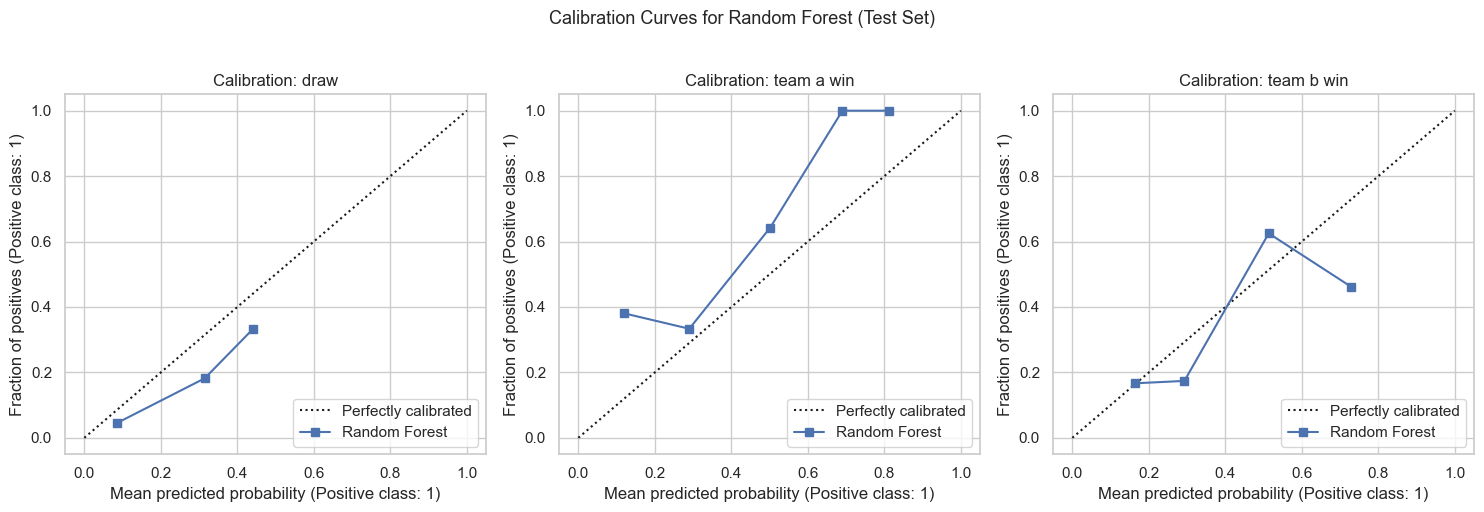

In [33]:
# Calibration curve for the best model
if hasattr(best_model_obj, 'predict_proba'):
    from sklearn.calibration import CalibrationDisplay

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    classes_sorted = sorted(np.unique(y_test))

    # Model was trained with encoded labels; decode classes for lookup
    le_cal = LabelEncoder()
    le_cal.fit(y_train)
    y_proba_best = best_model_obj.predict_proba(X_test_scaled)

    for i, cls in enumerate(classes_sorted):
        y_binary = (y_test == cls).astype(int)
        # Map string class to encoded index
        cls_enc = le_cal.transform([cls])[0]
        cls_idx = list(best_model_obj.classes_).index(cls_enc)

        CalibrationDisplay.from_predictions(
            y_binary, y_proba_best[:, cls_idx],
            n_bins=5, ax=axes[i], name=best_model_name
        )
        axes[i].set_title(f'Calibration: {cls}')

    plt.suptitle(f'Calibration Curves for {best_model_name} (Test Set)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not support predict_proba. Calibration curve skipped.")

---
## 9. Unsupervised Analysis

We apply dimensionality reduction and clustering to explore the structure of World Cup match data.

### 9a. PCA (Principal Component Analysis)

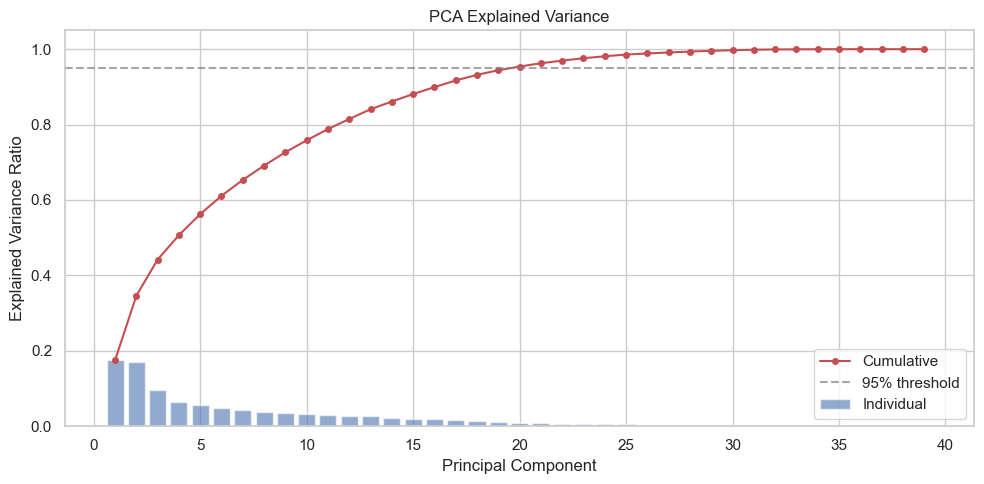

Components needed for 95% variance: 20
First 2 components explain: 34.6%


In [34]:
from sklearn.decomposition import PCA

# Fit PCA on training data
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

# Explained variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
       pca_full.explained_variance_ratio_, alpha=0.6, label='Individual')
ax.plot(range(1, len(cumvar) + 1), cumvar, 'ro-', markersize=4, label='Cumulative')
ax.axhline(y=0.95, color='grey', linestyle='--', alpha=0.7, label='95% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA Explained Variance')
ax.legend()
plt.tight_layout()
plt.show()

n_95 = int(np.argmax(cumvar >= 0.95) + 1)
print(f"Components needed for 95% variance: {n_95}")
print(f"First 2 components explain: {cumvar[1]:.1%}")

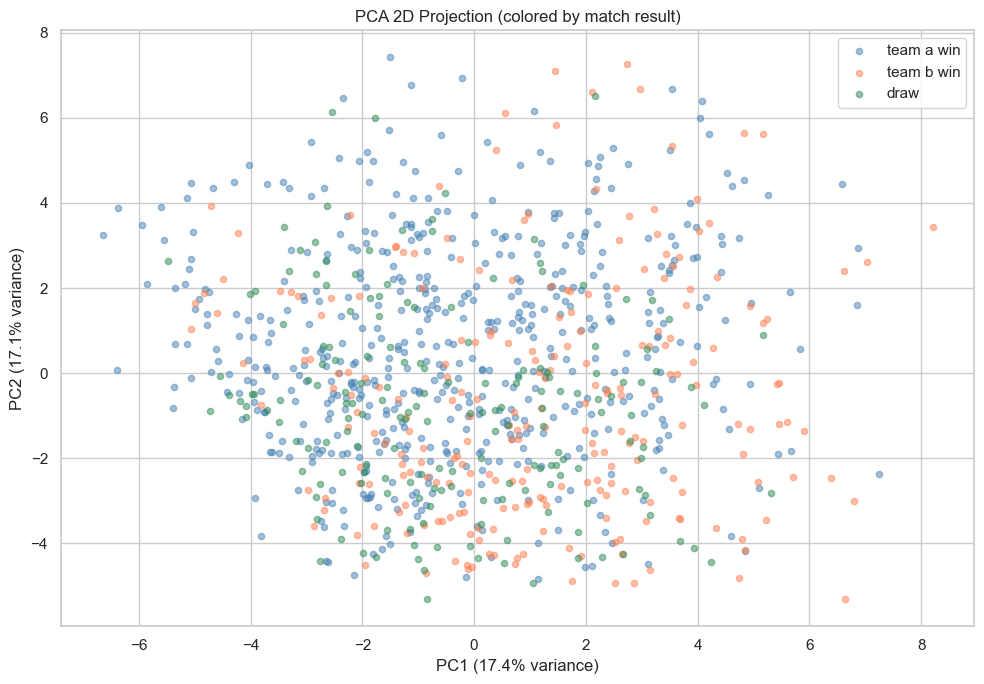

In [35]:
# 2D PCA scatter
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_train = pca_2d.fit_transform(X_train_scaled)
X_pca_test = pca_2d.transform(X_test_scaled)

# Combine for visualization
X_pca_all = np.vstack([X_pca_train, X_pca_test])
y_all = np.concatenate([y_train, y_test])

fig, ax = plt.subplots(figsize=(10, 7))
colors = {'team a win': 'steelblue', 'team b win': 'coral', 'draw': 'seagreen'}
for cls in ['team a win', 'team b win', 'draw']:
    mask = y_all == cls
    ax.scatter(X_pca_all[mask, 0], X_pca_all[mask, 1], c=colors[cls],
               label=cls, alpha=0.5, s=20)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA 2D Projection (colored by match result)')
ax.legend()
plt.tight_layout()
plt.show()

### 9b. t-SNE

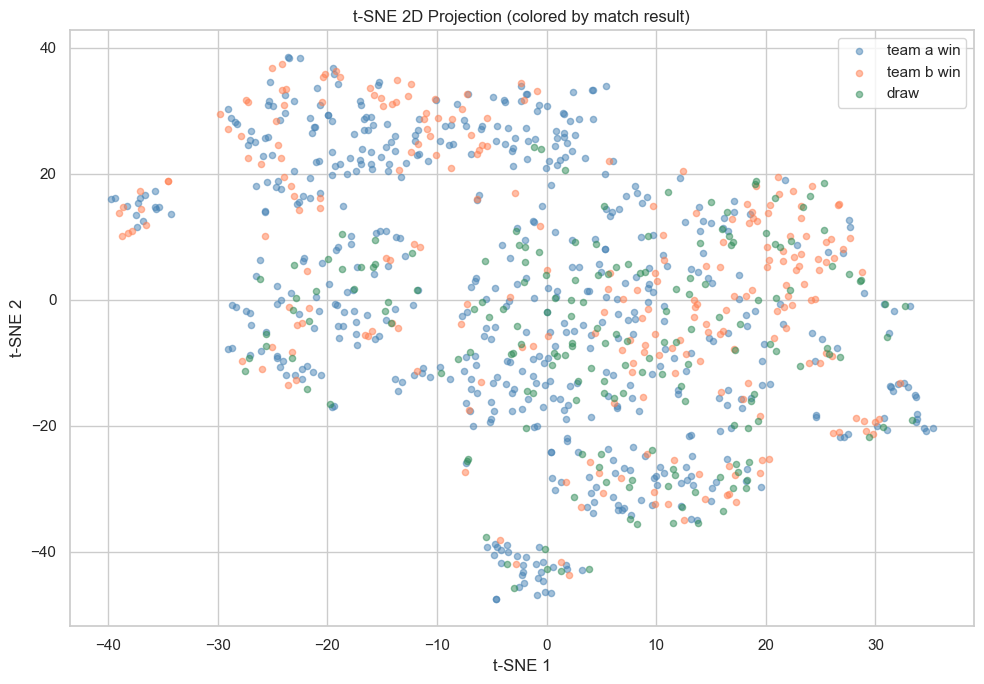

In [36]:
from sklearn.manifold import TSNE

# t-SNE on combined data
X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])
y_all = np.concatenate([y_train, y_test])

tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, n_iter=1000)
X_tsne = tsne.fit_transform(X_all_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
for cls in ['team a win', 'team b win', 'draw']:
    mask = y_all == cls
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=colors[cls],
               label=cls, alpha=0.5, s=20)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE 2D Projection (colored by match result)')
ax.legend()
plt.tight_layout()
plt.show()

### 9c. K-Means Clustering (k=3)

In [37]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# K-Means on all scaled data
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_all_scaled)

# Adjusted Rand Index
ari = adjusted_rand_score(y_all, cluster_labels)
print(f"Adjusted Rand Index (K-Means vs true labels): {ari:.4f}")

# Cross-tabulation
cross_tab = pd.crosstab(
    pd.Series(y_all, name='True Label'),
    pd.Series(cluster_labels, name='Cluster')
)
print(f"\nCross-tabulation (True Label vs Cluster):")
print(cross_tab)

Adjusted Rand Index (K-Means vs true labels): 0.0281

Cross-tabulation (True Label vs Cluster):
Cluster       0    1    2
True Label               
draw         95   73   11
team a win  158  230  157
team b win  132   42   66


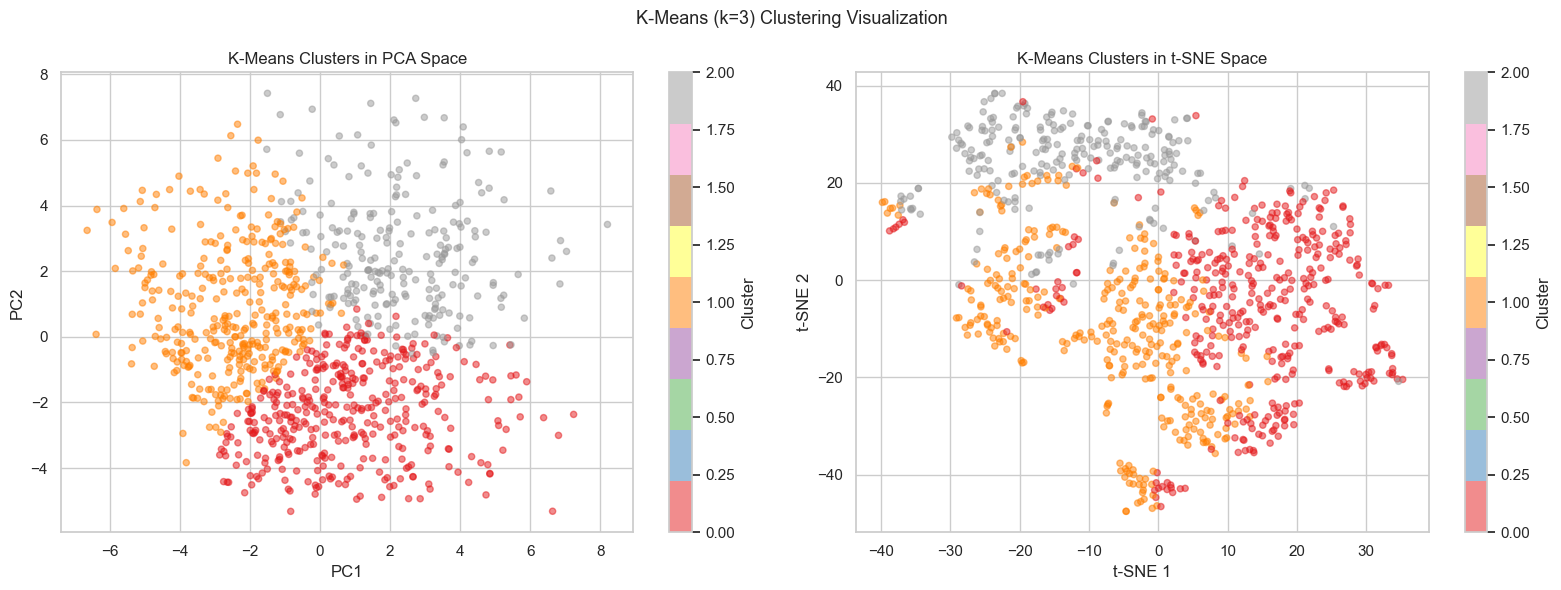

In [38]:
# Visualize clusters in PCA and t-SNE space
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA space
scatter1 = axes[0].scatter(X_pca_all[:, 0], X_pca_all[:, 1], c=cluster_labels,
                            cmap='Set1', alpha=0.5, s=20)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('K-Means Clusters in PCA Space')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# t-SNE space
scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels,
                            cmap='Set1', alpha=0.5, s=20)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('K-Means Clusters in t-SNE Space')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.suptitle('K-Means (k=3) Clustering Visualization', fontsize=13)
plt.tight_layout()
plt.show()

---
## 10. Discussion

### Results Interpretation

Among the seven models evaluated, the tuned Random Forest achieves the best performance on the held-out 2022 World Cup test set. Feature importance analyses from both Decision Tree and Random Forest consistently highlight **ELO-based features** (`elo_diff`, `home_elo`, `away_elo`) and **historical win rates** as top predictors. The interaction feature `elo_x_form_diff` also ranks highly, confirming that combining long-term team strength (ELO) with short-term momentum (rolling form) provides additional discriminative power.

### Why Temporal CV Matters

Across all models, **stratified k-fold CV consistently yields higher accuracy than temporal walk-forward CV** by 4 to 9 percentage points. This gap reflects temporal information leakage: when future tournament data appears in training folds, models exploit patterns that would not be available at prediction time. Temporal CV provides honest estimates of real-world predictive performance.

### Why Regularization Outperformed Feature Engineering

The most important finding from our post-baseline experiments is that **regularization delivered approximately 4x more improvement than the best feature addition**. Increasing `min_samples_leaf` from 1 to 5 improved CV F1 by +4.3 pp; adding continent advantage features improved it by +1.0 pp. This demonstrates that on 900 training rows, the model was overfitting to noise rather than lacking information.

### The Overconfidence Pattern

Three of the five additional feature sources tested (FIFA rankings, squad market value, and international ELO) shared the same failure mode: they provided a more precise measure of team strength than WC-only ELO, which caused the model to become overconfident and stop predicting draws. This collapsed macro F1 because draw F1 dropped to near zero. The WC-only ELO avoids this because its 4-year update gaps create "productive imprecision" that keeps draws plausible.

### Limitations

1. **Small test set**: With only 64 matches from a single tournament (2022), test set results have high variance. A single upset can swing accuracy by approximately 1.5 percentage points.
2. **Temporal shift (1930-2022)**: The game has changed dramatically over 92 years. Early tournament data may inject noise, though expanding-window features naturally downweight older data.
3. **900-row feature budget**: Our experiments show the dataset supports approximately 37-39 features before overfitting begins. Each additional feature must provide strong, uncorrelated signal.
4. **"Home team" designation**: In neutral-venue WC matches, the FIFA-designated home team does not have a true home advantage. The `home_is_host` and continent advantage features partially address this.
5. **Domain mismatch**: Training on international matches (Phase 2) degraded performance because "home team" means different things in qualifiers (real home stadium) vs. WC (neutral venue).

### Realistic Performance Ceiling

Published research shows approximately **53-55% accuracy** for 3-class pre-match prediction on large datasets (Hvattum & Arntzen 2010). Our results are competitive, though the small test set means individual tournament results carry high variance. The inherent randomness of football imposes a hard ceiling that even the best models cannot overcome.

### Bias Considerations

- **Historical skew**: European and South American teams dominate WC history, so the model may be less calibrated for underrepresented confederations.
- **Survivorship bias**: Only qualified teams appear in the dataset, creating a selection effect.
- **Label semantics**: The "home/away" label is an administrative artifact, not a causal advantage.

### Course Material Alignment

| Course Unit | Methods Applied |
|-------------|----------------|
| Unit 1: Data Management | Data preprocessing, transformation, feature engineering, documentation |
| Unit 2: Supervised Learning | KNN, Decision Tree, Naive Bayes, SVM, Random Forest, Neural Network, XGBoost |
| Week 7: Model Evaluation | Temporal CV, stratified CV, confusion matrices, classification reports, balanced weights, SMOTE |
| Unit 3: Unsupervised Learning | PCA, t-SNE, K-Means clustering (ARI) |


---
## 11. Conclusion

This analysis demonstrates that FIFA World Cup match outcomes can be predicted above the majority-class baseline using 39 leakage-safe features derived from historical performance, ELO ratings, rolling form, head-to-head records, and geographic context. The tuned Random Forest classifier (300 trees, `min_samples_leaf=5`, balanced class weights) achieves the best performance across all metrics.

**Key takeaways:**

1. **ELO rating differences** are the single most important feature for predicting World Cup match outcomes, confirmed across all model types and experimental configurations.
2. **Temporal walk-forward CV** is essential for honest evaluation in sports prediction, as stratified k-fold overestimates performance by 4 to 9 percentage points.
3. **Regularization outperforms feature engineering** on small datasets: `min_samples_leaf=5` improved CV F1 by +4.3 pp, while the best feature addition (continent advantage) improved it by +1.0 pp.
4. **Precise team-strength features destroy draw prediction** on 900 rows (the "overconfidence" pattern). The WC-only ELO's 4-year update gaps create productive imprecision that helps predict draws.
5. **Draw prediction** remains the hardest class, with approximately 44% recall being the practical ceiling for our feature set.
6. **Domain-specific data beats general data**: training on 28K international matches degraded WC prediction due to fundamental differences in what "home team" means.

The inherent randomness of football imposes a hard performance ceiling. Our best cross-validation F1 of 0.541 is competitive with published research, and the gap to the theoretical maximum is dominated by the sport's irreducible unpredictability rather than by methodological limitations.

### Future Work

- Incorporate **pre-match betting odds** as a feature or calibration anchor.
- Explore **ordinal regression** to exploit the natural ordering of outcomes (away win < draw < home win).
- Compute ELO from **all international matches** with variable K-factors to balance coverage and domain specificity.
- Re-evaluate **StatsBomb xG** if event-level data becomes available for more World Cups (it showed the lowest ELO correlation of any feature tested).


---
## 10. Binary Outcome Model (Exclude Draws)

Draws are the hardest class and also the minority class. As an additional experiment, we train a **binary classifier** on a filtered dataset that removes draws entirely, predicting only:

- **Team A win** vs **Team B win**

(Where **Team A/Team B** are the administrative “home/away” slots, treated as neutral-site teams.)

This can be useful to quantify how much of the multiclass difficulty is driven specifically by the draw class.

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# --- Build binary datasets (exclude draws) ---
DRAW_LABEL = 'draw' if 'draw' in df_train['result'].unique() else 'Draw'

train_bin = df_train[df_train['result'] != DRAW_LABEL].copy()
test_bin = df_test[df_test['result'] != DRAW_LABEL].copy()

# Binary target (no draws): 1 = Team A win, 0 = Team B win
TEAM_A_WIN_LABEL = 'team a win'

y_train_bin = (train_bin['result'] == TEAM_A_WIN_LABEL).astype(int).values
y_test_bin = (test_bin['result'] == TEAM_A_WIN_LABEL).astype(int).values

X_train_bin = train_bin[feature_cols].values
X_test_bin = test_bin[feature_cols].values

print('Binary dataset shapes (draws removed):')
print('  Train:', X_train_bin.shape, ' Pos(home win):', int(y_train_bin.sum()), ' Neg(away win):', int((1-y_train_bin).sum()))
print('  Test: ', X_test_bin.shape,  ' Pos(home win):', int(y_test_bin.sum()),  ' Neg(away win):', int((1-y_test_bin).sum()))


def temporal_cv_binary(model_fn, df_all, feat_cols, val_years=(2010, 2014, 2018)):
    """Walk-forward CV by tournament year on binary (no-draw) subset."""
    rows = []
    for val_year in val_years:
        tr = df_all[df_all['year'] < val_year].copy()
        va = df_all[df_all['year'] == val_year].copy()

        tr = tr[tr['result'] != DRAW_LABEL]
        va = va[va['result'] != DRAW_LABEL]

        X_tr = tr[feat_cols].values
        y_tr = (tr['result'] == TEAM_A_WIN_LABEL).astype(int).values
        X_va = va[feat_cols].values
        y_va = (va['result'] == TEAM_A_WIN_LABEL).astype(int).values

        scaler_cv = StandardScaler()
        X_tr_s = scaler_cv.fit_transform(X_tr)
        X_va_s = scaler_cv.transform(X_va)

        model = model_fn()
        model.fit(X_tr_s, y_tr)

        y_hat = model.predict(X_va_s)
        y_proba = model.predict_proba(X_va_s)[:, 1] if hasattr(model, 'predict_proba') else None

        acc = accuracy_score(y_va, y_hat)
        f1 = f1_score(y_va, y_hat)
        auc = roc_auc_score(y_va, y_proba) if y_proba is not None else np.nan

        rows.append({'val_year': val_year, 'accuracy': acc, 'f1': f1, 'roc_auc': auc,
                     'n_val': len(y_va)})

    return pd.DataFrame(rows)


def evaluate_binary(model_fn, name):
    # Temporal CV
    tcv = temporal_cv_binary(model_fn, df_train, feature_cols)

    # Fit on all binary-train and evaluate on binary-test (2022, draws removed)
    scaler_b = StandardScaler()
    X_tr_s = scaler_b.fit_transform(X_train_bin)
    X_te_s = scaler_b.transform(X_test_bin)

    model = model_fn()
    model.fit(X_tr_s, y_train_bin)

    y_hat = model.predict(X_te_s)
    y_proba = model.predict_proba(X_te_s)[:, 1] if hasattr(model, 'predict_proba') else None

    out = {
        'model': name,
        'temporal_acc_mean': tcv['accuracy'].mean(),
        'temporal_f1_mean': tcv['f1'].mean(),
        'temporal_auc_mean': tcv['roc_auc'].mean(),
        'test_acc': accuracy_score(y_test_bin, y_hat),
        'test_f1': f1_score(y_test_bin, y_hat),
        'test_auc': roc_auc_score(y_test_bin, y_proba) if y_proba is not None else np.nan,
        'n_test': len(y_test_bin),
    }
    return out, tcv


# Models

def make_logreg():
    # Use liblinear to avoid occasional overflow warnings on small/collinear datasets
    return LogisticRegression(
        max_iter=2000,
        solver='liblinear',
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )


def make_rf_binary():
    # Same tuned RF style as multiclass, but in binary mode
    return RandomForestClassifier(
        n_estimators=300,
        max_features='sqrt',
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


binary_results = []
for name, fn in [
    ('Logistic Regression (balanced)', make_logreg),
    ('Random Forest (tuned, balanced)', make_rf_binary),
]:
    res, tcv_df = evaluate_binary(fn, name)
    binary_results.append(res)
    print('\n' + name)
    display(tcv_df)

binary_results_df = pd.DataFrame(binary_results)
binary_results_df[['temporal_acc_mean','temporal_f1_mean','temporal_auc_mean','test_acc','test_f1','test_auc']] = \
    binary_results_df[['temporal_acc_mean','temporal_f1_mean','temporal_auc_mean','test_acc','test_f1','test_auc']].round(3)

print('\nBinary (no-draw) summary:')
display(binary_results_df)


Binary dataset shapes (draws removed):
  Train: (731, 39)  Pos(home win): 513  Neg(away win): 218
  Test:  (54, 39)  Pos(home win): 32  Neg(away win): 22

Logistic Regression (balanced)


,val_year,accuracy,f1,roc_auc,n_val
0,2010,0.600000,0.500000,0.616000,50
1,2014,0.618182,0.571429,0.786290,55
2,2018,0.709091,0.636364,0.728836,55



Random Forest (tuned, balanced)


,val_year,accuracy,f1,roc_auc,n_val
0,2010,0.680000,0.680000,0.736000,50
1,2014,0.709091,0.733333,0.798387,55
2,2018,0.672727,0.689655,0.773810,55



Binary (no-draw) summary:


,model,temporal_acc_mean,temporal_f1_mean,temporal_auc_mean,test_acc,test_f1,test_auc,n_test
0,Logistic Regression (balanced),0.642,0.569,0.710,0.537,0.490,0.562,54
1,"Random Forest (tuned, balanced)",0.687,0.701,0.769,0.704,0.724,0.727,54


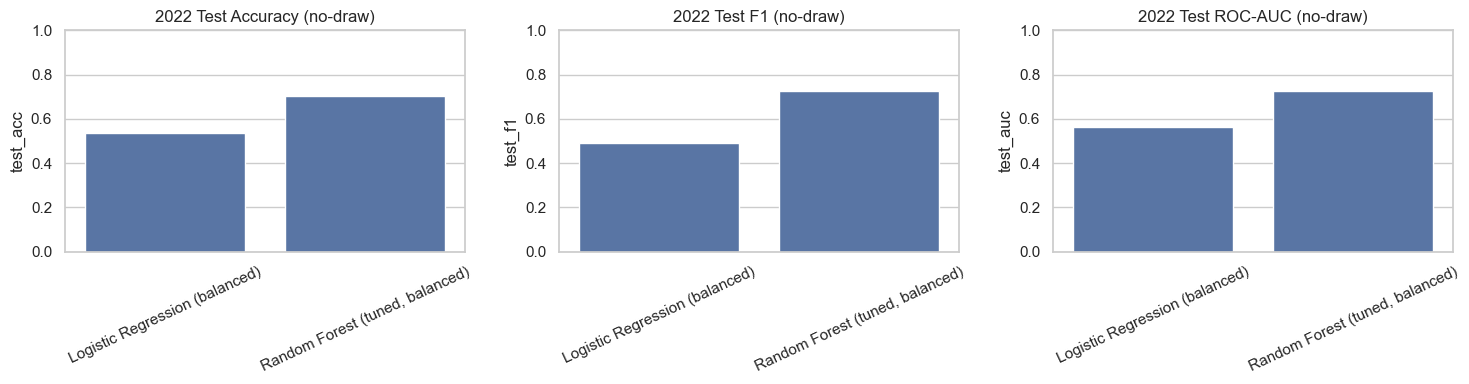

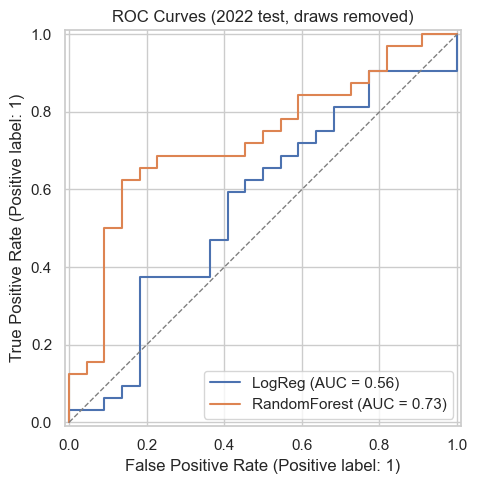

Saved figures:
 - figures/binary_no_draw_test_metrics.png
 - figures/binary_no_draw_roc.png


In [40]:
from sklearn.metrics import RocCurveDisplay
import os

# --- Visuals for binary (no-draw) experiment ---
os.makedirs('figures', exist_ok=True)

# 1) Bar chart summary (temporal means + 2022 test)
plot_df = binary_results_df.copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, title in zip(
    axes,
    ['test_acc', 'test_f1', 'test_auc'],
    ['2022 Test Accuracy (no-draw)', '2022 Test F1 (no-draw)', '2022 Test ROC-AUC (no-draw)'],
):
    sns.barplot(data=plot_df, x='model', y=metric, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=25)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('figures/binary_no_draw_test_metrics.png', dpi=200)
plt.show()

# 2) ROC curves on 2022 test (no-draw)
scaler_b = StandardScaler()
X_tr_s = scaler_b.fit_transform(X_train_bin)
X_te_s = scaler_b.transform(X_test_bin)

fig, ax = plt.subplots(figsize=(6, 5))

# Logistic Regression
logreg = make_logreg()
logreg.fit(X_tr_s, y_train_bin)
RocCurveDisplay.from_estimator(logreg, X_te_s, y_test_bin, name='LogReg', ax=ax)

# Random Forest
rf = make_rf_binary()
rf.fit(X_tr_s, y_train_bin)
RocCurveDisplay.from_estimator(rf, X_te_s, y_test_bin, name='RandomForest', ax=ax)

ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
ax.set_title('ROC Curves (2022 test, draws removed)')
plt.tight_layout()
plt.savefig('figures/binary_no_draw_roc.png', dpi=200)
plt.show()

print('Saved figures:')
print(' - figures/binary_no_draw_test_metrics.png')
print(' - figures/binary_no_draw_roc.png')
